In [1]:
%pip install plotly -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── Core Libraries ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Display & Formatting ───────────────────────────────────────────────────────
from IPython.display import display, HTML, Markdown
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("giza_weather_clean.csv")

In [9]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

In [10]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1096 entries, 2022-08-01 to 2025-07-31
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temp_avg_c       1096 non-null   float64
 1   temp_max_c       1096 non-null   float64
 2   temp_min_c       1096 non-null   float64
 3   precip_mm        1096 non-null   float64
 4   humidity_pct     1096 non-null   float64
 5   windspeed_ms     1096 non-null   float64
 6   cloud_cover_pct  1096 non-null   float64
dtypes: float64(7)
memory usage: 68.5 KB


In [11]:
df.describe()

,temp_avg_c,temp_max_c,temp_min_c,precip_mm,humidity_pct,windspeed_ms,cloud_cover_pct
count,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000
mean,22.584599,30.438659,15.769781,0.336177,52.500338,2.780356,25.270922
std,6.872355,7.621071,5.871208,2.368778,13.369643,0.805054,22.195351
min,8.320000,13.750000,2.650000,0.000000,15.880000,0.750000,0.280000
25%,15.957500,23.317500,10.410000,0.000000,43.107500,2.230000,8.432500
50%,22.865000,31.030000,15.870000,0.000000,51.220000,2.780000,18.835000
75%,29.332500,37.842500,21.327500,0.010000,62.592500,3.300000,34.730000
max,35.050000,45.490000,27.510000,42.540000,84.600000,5.700000,99.890000


In [12]:
df.head(4)

,temp_avg_c,temp_max_c,temp_min_c,precip_mm,humidity_pct,windspeed_ms,cloud_cover_pct
date,,,,,,,
2022-08-01,30.93,40.58,22.66,0.18,48.52,3.40,19.79
2022-08-02,30.01,38.79,21.79,0.06,49.87,3.24,22.09
2022-08-03,29.69,38.35,21.44,0.02,46.99,3.60,4.11
2022-08-04,30.06,38.95,21.37,0.00,48.71,2.95,21.89


In [13]:
df.index

DatetimeIndex(['2022-08-01', '2022-08-02', '2022-08-03', '2022-08-04',
               '2022-08-05', '2022-08-06', '2022-08-07', '2022-08-08',
               '2022-08-09', '2022-08-10',
               ...
               '2025-07-22', '2025-07-23', '2025-07-24', '2025-07-25',
               '2025-07-26', '2025-07-27', '2025-07-28', '2025-07-29',
               '2025-07-30', '2025-07-31'],
              dtype='datetime64[us]', name='date', length=1096, freq=None)

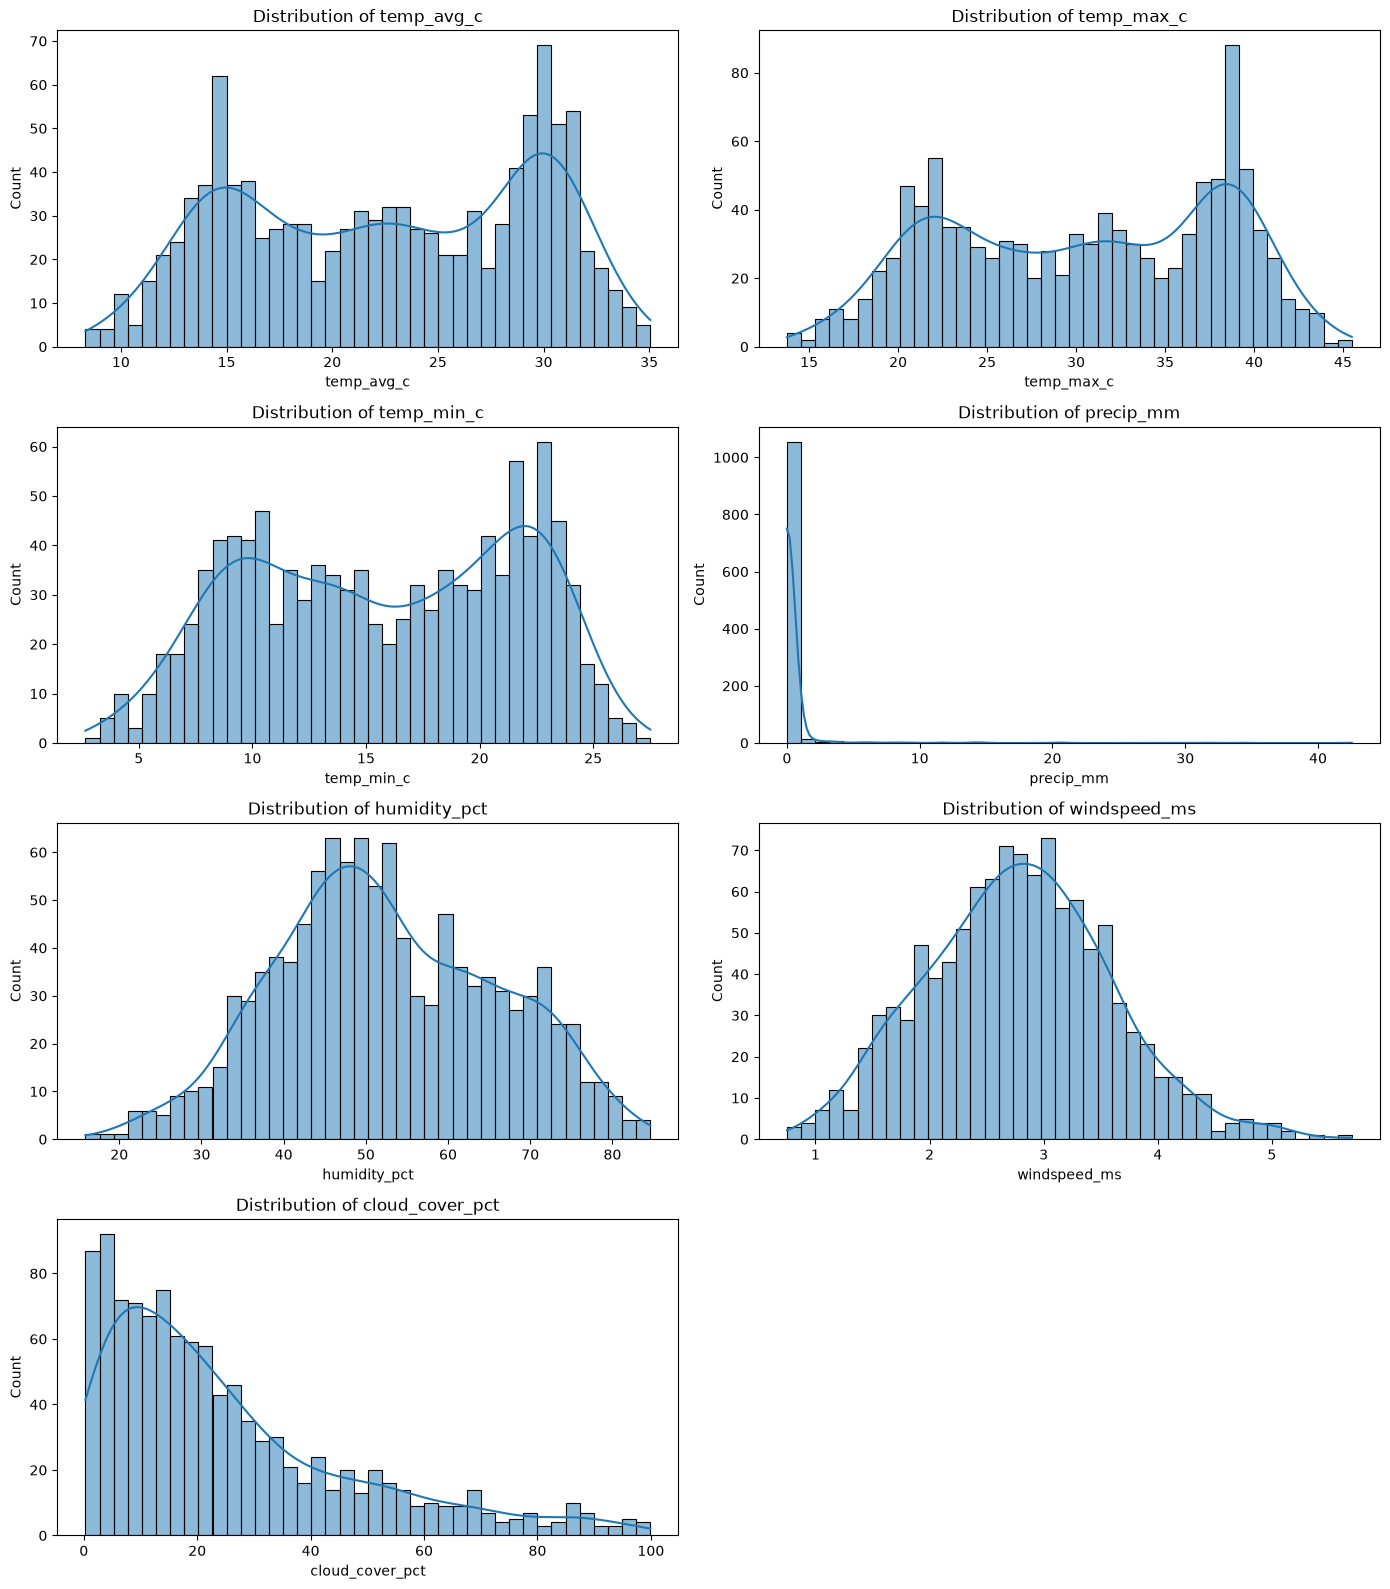

In [18]:
cols = ['temp_avg_c', 'temp_max_c', 'temp_min_c', 'precip_mm',
        'humidity_pct', 'windspeed_ms', 'cloud_cover_pct']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=40)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

# hide unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

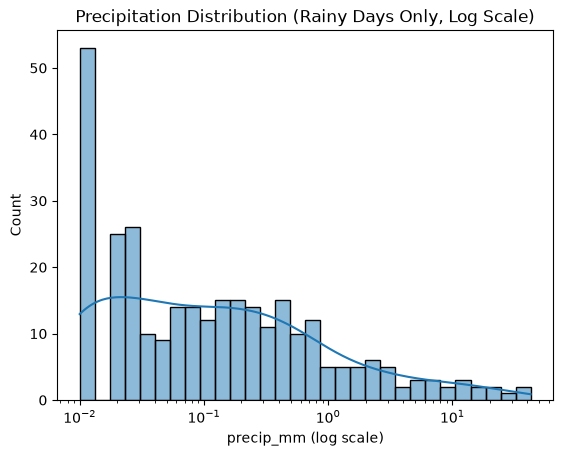

In [21]:
sns.histplot(rainy_days, kde=True, bins=30, log_scale=True)
plt.title('Precipitation Distribution (Rainy Days Only, Log Scale)')
plt.xlabel('precip_mm (log scale)')
plt.show()

In [20]:
(df['precip_mm'] == 0).mean() * 100   # % of days with zero rain

np.float64(72.53649635036497)